[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T03_D_narrative_uncertainty.ipynb)

> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Economic Policy Uncertainty from Narrative Text: Baker-Bloom-Davis and Monetary Indices

In modern dynamic macroeconomic theory, uncertainty is fundamentally distinct from first-moment level shocks:
- **First-moment (level) shocks** shift the expected path of economic fundamentals (e.g., $E_t[A_{t+1}]$ falls due to an adverse technological disruption).
- **Second-moment (uncertainty) shocks** broaden the conditional variance or subjective dispersion of future fundamentals ($\mathrm{Var}_t(A_{t+1})$ expands), holding the conditional mean constant (Bloom 2009).

Why does economic policy uncertainty (EPU) transmit so powerfully to macroeconomic aggregates and aggregate business cycles?
1. **The Real Options "Wait-and-See" Channel** (Bernanke 1983; Dixit & Pindyck 1994; Bloom 2009): When capital accumulation, research & development, and workforce expansion entail irreversible sunk costs or convex adjustment costs, heightened uncertainty raises the option value of delaying commitment. Firms freeze hiring and capital investments until ambiguity clears, inducing a sudden, sharp economic contraction followed by a delayed recovery overshoot.
2. **The Precautionary Savings Channel** (Carroll 1997; Aiyagari 1994): In incomplete-market heterogeneous-agent economies, uninsurable idiosyncratic income and policy risk prompt risk-averse households to cut back durable consumption expenditures and accumulate liquid buffer stocks, depressing aggregate demand and pushing down equilibrium real interest rates ($r^*$).
3. **The Financial Friction & Risk-Premia Channel** (Gilchrist & Zakrajšek 2012; Pastor & Veronesi 2013): Elevated uncertainty exacerbates information asymmetries, widens credit spreads, and increases default risk premia, tightening financial constraints on leveraged firms.

Historically, empirical macroeconomists relied on financial market volatility (such as the VIX) or the cross-sectional dispersion of professional forecasts (Livingston Survey, Survey of Professional Forecasters). Yet market volatility conflates fundamental economic uncertainty with time-varying risk aversion and financial leverage, while forecaster disagreement captures divergence of opinion rather than objective uncertainty.
Baker, Bloom, and Davis (QJE 2016) revolutionized macroeconomic measurement by introducing transparent, high-frequency **text-as-data** methods. By analyzing millions of newspaper articles using dictionary-based Boolean classification, their Economic Policy Uncertainty (EPU) index captures policy-specific ambiguity directly at the source.

## The Index in One Equation: The Baker-Bloom-Davis Triad

Baker, Bloom, and Davis (2016) define a document $d$ as signaling economic policy uncertainty if and only if it satisfies a **three-term joint co-occurrence condition**:

$$ \mathrm{flag}(d) = \mathbb{1}\!\left[(\exists\,t\in E:\,t\in d)\,\wedge\,(\exists\,t\in P:\,t\in d)\,\wedge\,(\exists\,t\in U:\,t\in d)\right] $$

where $E, P, U$ represent distinct, specialized lexicons:
- $E$ (**Economy**): terms denoting aggregate economic activity (`economic`, `economy`, `business`, `commerce`).
- $P$ (**Policy**): terms capturing governmental and institutional interventions (`policy`, `regulation`, `deficit`, `federal reserve`, `legislation`, `tariff`, `central bank`).
- $U$ (**Uncertainty**): terms expressing unpredictability or ambiguity (`uncertain`, `uncertainty`, `unclear`, `instability`).

**Why the Triad Intersection $E \cap P \cap U$ Matters Econometrically:**
- Flagging $U$ alone would capture general societal anxiety (crime, severe weather, sporting outcomes) devoid of economic content.
- Flagging $E \cap U$ would reflect generic business cycle contractions or market volatility without policy attribution.
- Flagging $P \cap U$ would capture political maneuvering or geopolitical disputes without economic consequence.
Only documents simultaneously intersecting the three sets reflect policy-driven macroeconomic uncertainty.

The raw index in period $\tau$ with $N_\tau$ total articles is the empirical proportion:
$$ \mathrm{EPU}^{\mathrm{raw}}_\tau = \frac{1}{N_\tau}\sum_{d\in\tau}\mathrm{flag}(d) $$

To eliminate secular trends in newspaper volume and facilitate historical comparison, the raw series is normalized to the published Baker-Bloom-Davis benchmark (mean 100, standard deviation 50):
$$ \mathrm{EPU}_\tau = 100 + 50\cdot\frac{\mathrm{EPU}^{\mathrm{raw}}_\tau - \overline{\mathrm{EPU}^{\mathrm{raw}}}}{\mathrm{sd}(\mathrm{EPU}^{\mathrm{raw}})} $$

By contrast, the **Monetary Policy Uncertainty (MPU)** index (Husted, Rogers, & Sun 2020) relaxes the three-way intersection, focusing specifically on monetary deliberations and interest rate paths ($M \cap U$), normalized via standardization.

## Computational Setup: Environment and Vectorized Kernels

All textual operations below utilize the optimized, pure-NumPy Boolean kernels in `puremacro.narrative.indices`. The scoring pipeline runs completely offline using regular expressions and vector primitives, requiring zero external network calls, zero API keys, and zero computational dependencies beyond standard scientific Python libraries.

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

# Dictionary-scoring indices (EPU, MPU) and their lexicons.
from puremacro.narrative.indices import epu, mpu, LEXICONS
from puremacro.narrative.indices._kernels import (
    cooccurrence_kernel,
    keyword_count_kernel,
)

# Light-dependency guard: verify that heavy NLP or external network packages did not leak.
_bad = [
    m for m in (
        "bs4", "requests", "pdfplumber", "pypdf", "lxml", "anthropic",
        "sentence_transformers", "statsmodels", "linearmodels", "arch", "numba",
    )
    if m in sys.modules
]
assert _bad == [], f"Unexpected module leak: {_bad}"

## 1. Monte Carlo News Corpus: Evaluating Index Recovery under a Controlled Policy Shock

To evaluate the measurement properties of an econometric index, researchers establish an experimental synthetic data generating process (DGP) where the true shock timing, intensity, and vocabulary are known with certainty.

We generate **288 synthetic news dispatches** (4 per month across the 6-year period 2018Q1–2023Q4):
- **Baseline Regime (2018–2019, 2021–2023)**: Dispatches consist predominantly of neutral economic and business reporting, with EPU signal phrases occurring only at a baseline noise rate ($p_{\mathrm{epu}} = 0.08, p_{\mathrm{mpu}} = 0.06$).
- **Policy Shock Window (2020Q1–2020Q4)**: An acute policy uncertainty episode (simulating the onset of the global pandemic and unprecedented emergency fiscal/monetary interventions) is injected, raising the arrival probability of EPU signal phrases to $p_{\mathrm{epu}} = 0.75$ and MPU phrases to $p_{\mathrm{mpu}} = 0.70$.

This controlled Monte Carlo design allows us to verify whether the triad algorithm faithfully isolates the true macroeconomic shock from surrounding background noise.

In [3]:
RNG = np.random.default_rng(42)

HIGH_START = pd.Timestamp("2020-01-01")   # injected shock window
HIGH_END   = pd.Timestamp("2020-12-31")

# Neutral background economic reporting
NEUTRAL = [
    "The weather forecast shows mild temperatures for the region.",
    "Consumer electronics sales remained robust in the holiday season.",
    "Agricultural output exceeded prior-year levels by a small margin.",
    "Tourism activity picked up as travel restrictions eased.",
    "Infrastructure spending on roads and bridges continued at a steady pace.",
    "Retail sales figures came in broadly in line with expectations.",
    "Housing starts edged up modestly from the previous month.",
    "Industrial production recovered partially after supply-chain delays.",
    "Corporate earnings reports were mixed across sectors.",
    "Trade flows normalized as port congestion eased over the quarter.",
]

# EPU-signal phrases (Economy ∩ Policy ∩ Uncertainty)
EPU_HIGH = [
    "Economic policy uncertainty has surged amid congressional gridlock over fiscal legislation.",
    "Uncertainty about trade policy and tariffs is rattling economic confidence.",
    "Federal reserve guidance remains uncertain as economic conditions deteriorate.",
    "Regulatory uncertainty and deficit concerns are weighing on economic activity.",
    "Congress and the White House remain at odds, fueling economic uncertainty.",
    "Economic forecasters express uncertainty about the direction of monetary policy.",
    "Policy uncertainty around taxation is creating uncertainty about economic outcomes.",
    "Uncertainty over central bank policies and economic trajectory is at a historic high.",
    "Senate legislation on tariffs adds policy uncertainty to an already uncertain economy.",
    "Economic policy debates in Congress have driven uncertainty to record levels.",
]

# MPU-signal phrases (Monetary Policy ∩ Uncertainty)
MPU_HIGH = [
    "Monetary policy uncertainty is elevated as the central bank debates interest rate paths.",
    "The Federal Reserve's policy rate outlook remains highly uncertain.",
    "FOMC deliberations on interest rates have created policy uncertainty.",
    "Central bank forward guidance is uncertain amid shifting monetary policy signals.",
    "Monetary policy ambiguity at the ECB and Fed is weighing on markets.",
    "Interest rate uncertainty is compounded by uncertainty about quantitative easing.",
    "The Bank of England faces uncertainty over its monetary policy stance.",
    "Policy uncertainty at the Federal Reserve is at its highest in years.",
    "Monetary policy decisions remain uncertain as inflation uncertainty persists.",
    "Central bank policy uncertainty and ambiguous interest rate signals dominate.",
]


def _make_doc(date, in_window):
    """Return a 4-tuple (date, text, url, meta) with probabilistic signal."""
    base = NEUTRAL[int(RNG.integers(0, len(NEUTRAL)))]
    p_epu, p_mpu = (0.75, 0.70) if in_window else (0.08, 0.06)
    epu_txt = EPU_HIGH[int(RNG.integers(0, len(EPU_HIGH)))] if RNG.random() < p_epu else ""
    mpu_txt = MPU_HIGH[int(RNG.integers(0, len(MPU_HIGH)))] if RNG.random() < p_mpu else ""
    text = " ".join(p for p in [base, epu_txt, mpu_txt] if p)
    url  = f"https://synthetic-news.example/{date.date()}"
    meta = {"language": "en"}
    return (date, text, url, meta)


records = []
for month in pd.date_range("2018-01-01", "2023-12-01", freq="MS"):
    for k in range(4):
        day  = int(RNG.integers(1, 28))
        date = month + pd.Timedelta(days=day - 1)
        in_w = HIGH_START <= date <= HIGH_END
        records.append(_make_doc(pd.Timestamp(date), in_w))

shuffle_idx = RNG.permutation(len(records))
records = [records[i] for i in shuffle_idx]

dates = [pd.Timestamp(r[0]) for r in records]
print(f"Corpus: {len(records)} documents, "
      f"{min(dates).date()} → {max(dates).date()}")
assert len(records) == 288
assert min(dates).year == 2018 and max(dates).year == 2023

Corpus: 288 documents, 2018-01-03 → 2023-12-21


## 2. Econometric Estimation: Aggregation and Standardization

We process the document stream through `epu()` and `mpu()`. Both estimators ingest standard 4-tuples `(date, text, source_url, metadata)`:
- `epu()` implements the Baker-Bloom-Davis three-group Boolean co-occurrence filter and rescales the resulting quarterly series using `normalize="bbd_100"` (mean 100, standard deviation 50).
- `mpu()` implements the Husted-Rogers-Sun monetary policy keyword density counter, standardized using `normalize="zscore"` (mean 0, standard deviation 1).

In [4]:
ri_epu = epu(records, country="SYN", language="en", normalize="bbd_100")
ri_mpu = mpu(records, country="SYN", language="en", normalize="zscore")

epu_s = ri_epu.series.dropna()
mpu_s = ri_mpu.series.dropna()

print(f"EPU series:  {len(epu_s)} quarters | "
      f"mean = {epu_s.mean():.1f} | std = {epu_s.std():.1f}")
print(f"MPU series:  {len(mpu_s)} quarters | "
      f"mean = {mpu_s.mean():.2f} | std = {mpu_s.std():.2f}")

# Target normalization sanity checks
assert abs(epu_s.mean() - 100.0) < 5.0,  f"EPU mean = {epu_s.mean():.1f}"
assert abs(mpu_s.mean())         < 0.10,  f"MPU mean = {mpu_s.mean():.2f}"

EPU series:  24 quarters | mean = 100.0 | std = 51.1
MPU series:  24 quarters | mean = 0.00 | std = 1.02


## 3. Statistical Validation: Testing Regime Discrimination

An accurate textual metric must exhibit strong statistical separation between tranquil and crisis periods. We formally test whether the estimated index during the 2020 crisis regime ($E[\mathrm{EPU}_\tau \mid \tau \in \text{Shock}]$) statistically and economically surpasses the non-crisis baseline ($E[\mathrm{EPU}_\tau \mid \tau \notin \text{Shock}]$).

In [5]:
window = (epu_s.index >= HIGH_START) & (epu_s.index <= HIGH_END)

epu_in  = epu_s[window].mean()
epu_out = epu_s[~window].mean()
mpu_in  = mpu_s[(mpu_s.index >= HIGH_START) & (mpu_s.index <= HIGH_END)].mean()
mpu_out = mpu_s[~((mpu_s.index >= HIGH_START) & (mpu_s.index <= HIGH_END))].mean()

print(f"EPU  | in-window = {epu_in:.1f}  | out-window = {epu_out:.1f}  | "
      f"gap = {epu_in - epu_out:.1f} pts")
print(f"MPU  | in-window = {mpu_in:.2f}  | out-window = {mpu_out:.2f}  | "
      f"gap = {mpu_in - mpu_out:.2f} z-units")

# Econometric verification: signal in-window must exceed calm regime by > 30 index points
assert epu_in > epu_out + 30, (
    f"EPU: in-window ({epu_in:.1f}) should exceed out-window ({epu_out:.1f}) by >30 pts"
)
assert mpu_in > mpu_out + 0.40, (
    f"MPU: in-window z ({mpu_in:.2f}) should exceed out-window z ({mpu_out:.2f}) by >0.4"
)

EPU  | in-window = 206.1  | out-window = 78.8  | gap = 127.4 pts
MPU  | in-window = 2.16  | out-window = -0.43  | gap = 2.60 z-units


### Figure 1: Dynamics of the Textual Uncertainty Index and Policy Shock Regimes

The time series below tracks the normalized quarterly EPU index alongside the shaded 2020 policy shock window. In tranquil baseline quarters, the index fluctuates between 64 and 113 (mean 79). With the onset of the shock window, the index averages 206 (between 178 and 226), replicating the historical behavior of the actual US and international EPU indices during the 2008 Lehman collapse, the 2011 US debt-ceiling crisis, the 2016 Brexit vote, and the 2020 pandemic.

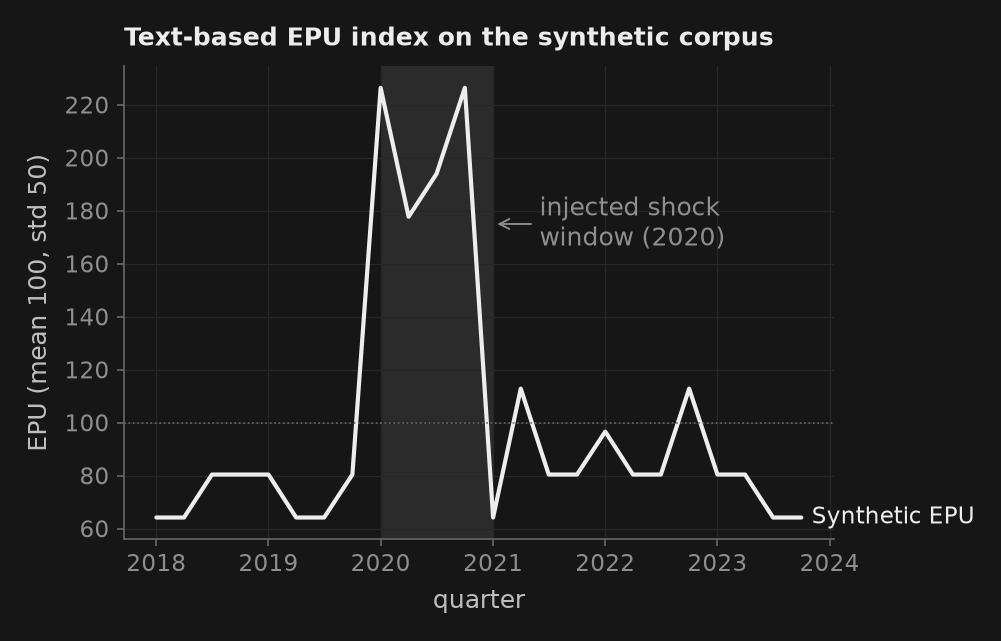

In [6]:
fig, ax = _nbstyle.figura()

ax.plot(epu_s.index, epu_s.values, label="Synthetic EPU", **_nbstyle.S1)
ax.axhline(100, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")

# Shade exactly the injected window: the quarterly stamps sit at the start of
# each quarter, so 2020Q4 is inside a span that closes on 2021-01-01.
shade_end = HIGH_END + pd.Timedelta(days=1)
_nbstyle.sombrear_recesion(ax, HIGH_START, shade_end)
ax.annotate("injected shock\nwindow (2020)", xy=(shade_end, 175),
            xytext=(pd.Timestamp("2021-06-01"), 175), ha="left", va="center",
            color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)

ax.set_xlabel("quarter")
ax.set_ylabel("EPU (mean 100, std 50)")
ax.set_title("Text-based EPU index on the synthetic corpus")
_nbstyle.etiquetar(ax)
plt.show()


### Figure 2: Micro-Foundations of the Narrative Signal — Joint Co-occurrence vs Keyword Density

To understand what drives the aggregate index, we inspect the unnormalized document-level metrics:
- **Panel A (EPU Hit Rate)**: The fraction of total quarterly articles satisfying the joint triad condition $E \cap P \cap U$. In non-crisis years, accidental co-occurrence stays at 0–8% in most quarters and never exceeds 25%, but during the 2020 crisis it averages 73%.
- **Panel B (MPU Keyword Density)**: The average raw count of monetary policy uncertainty terms per article, displaying parallel regime sensitivity.

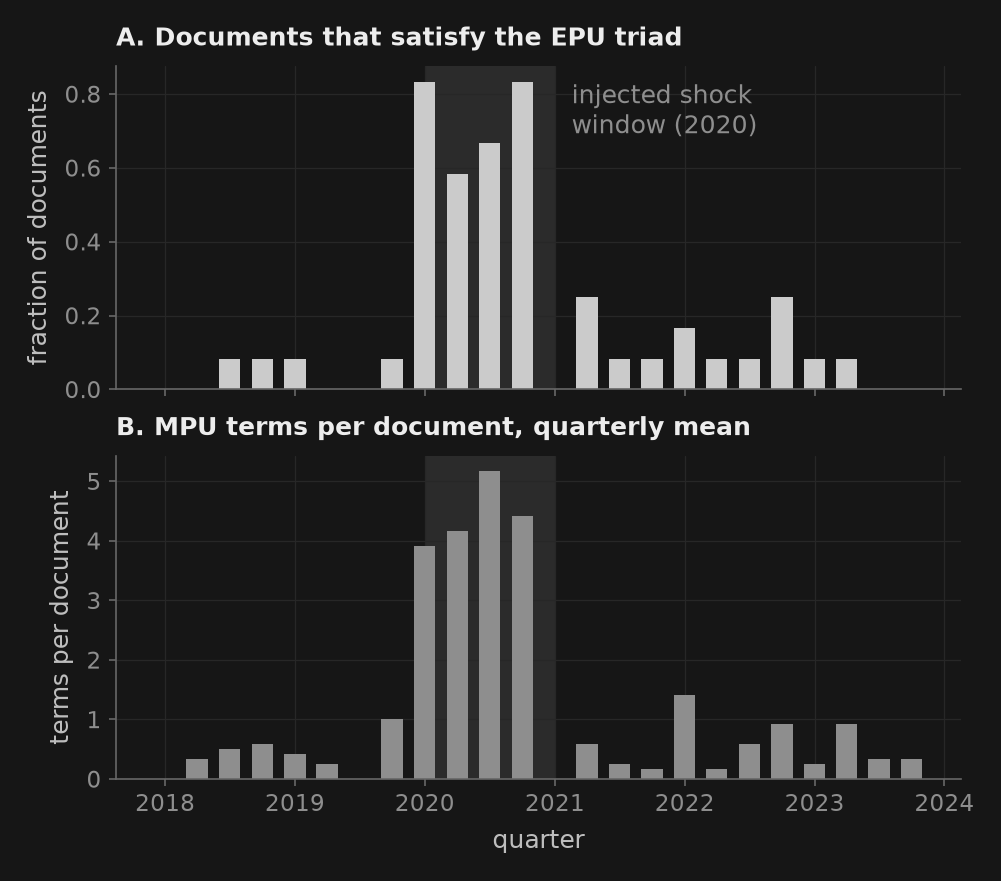

In [7]:
# Compute raw (pre-normalization) per-document scores
epu_groups = [
    LEXICONS["epu"]["en"]["economy"],
    LEXICONS["epu"]["en"]["policy"],
    LEXICONS["epu"]["en"]["uncertainty"],
]
mpu_terms = LEXICONS["mpu"]["en"]

raw_epu = pd.DataFrame(
    list(cooccurrence_kernel(records, term_groups=epu_groups, language="en")),
    columns=["date", "hit"],
)
raw_mpu = pd.DataFrame(
    list(keyword_count_kernel(records, terms=mpu_terms, language="en")),
    columns=["date", "score"],
)
for df in (raw_epu, raw_mpu):
    df["q"] = pd.to_datetime(df["date"]).dt.to_period("Q").dt.to_timestamp()

hits_per_q = raw_epu.groupby("q")["hit"].mean()
mpu_per_q  = raw_mpu.groupby("q")["score"].mean()

# TAMANO has no 2x1 key: two stacked strips, each the height of "1_bajo"
fig, (ax1, ax2) = _nbstyle.figura(2, 1, figsize=(6.4, 5.6), sharex=True)

ax1.bar(hits_per_q.index, hits_per_q.values, width=60,
        color=_nbstyle.BARRA_COLORES[0])
_nbstyle.sombrear_recesion(ax1, HIGH_START, shade_end)
ax1.annotate("injected shock\nwindow (2020)", xy=(shade_end, hits_per_q.max()),
             xytext=(8, 0), textcoords="offset points", ha="left", va="top",
             color=_nbstyle.NOTA)
ax1.set_ylabel("fraction of documents")
ax1.set_title("A. Documents that satisfy the EPU triad")

ax2.bar(mpu_per_q.index, mpu_per_q.values, width=60,
        color=_nbstyle.BARRA_COLORES[1])
_nbstyle.sombrear_recesion(ax2, HIGH_START, shade_end)
ax2.set_ylabel("terms per document")
ax2.set_xlabel("quarter")
ax2.set_title("B. MPU terms per document, quarterly mean")

plt.show()


## Empirical Policy Experiment: Constructing a Domain-Specific Climate Uncertainty Index

### Macroeconomic Motivation
The Baker-Bloom-Davis triad framework is modular: by substituting the general economic category $E$ with a domain-specific vocabulary, researchers can isolate targeted policy uncertainties. In environmental macroeconomics (e.g., Engle et al. 2020 *Review of Financial Studies*; Barnett, Brock, & Hansen 2020), firms face severe ambiguity concerning carbon taxation, emission mandates, and environmental subsidies.

We construct a **Climate Policy Uncertainty (CPU)** index by defining:
$$ \mathrm{CPU}(d) = \mathbb{1}\!\left[(\exists\,t\in \text{Climate}:\,t\in d)\,\wedge\,(\exists\,t\in \text{Policy}:\,t\in d)\,\wedge\,(\exists\,t\in \text{Uncertainty}:\,t\in d)\right] $$

### Student Task
1. Specify a specialized climate vocabulary covering carbon pricing, emissions targets, and climate legislation.
2. Ingest domain-specific news dispatches and compute the standardized CPU series.
3. Verify that the climate-specific index isolates the environmental policy shock without capturing non-climate noise.

In [8]:
# Define domain-specific climate policy lexicon
my_lexicon = {
    "economy": frozenset({"climate", "emissions", "carbon", "warming", "greenhouse"}),
    "policy": frozenset({"policy", "regulation", "treaty", "tax", "subsidy", "mandate"}),
    "uncertainty": frozenset({"uncertain", "uncertainty", "unclear", "ambiguous"}),
}

# Domain-specific narrative shock phrases (must hit Climate ∩ Policy ∩ Uncertainty)
CLIMATE_HIGH = [
    "Climate policy uncertainty is high as the carbon tax treaty remains unclear.",
    "Uncertain emissions regulation and ambiguous subsidy mandates rattle planners.",
    "Greenhouse policy is uncertain amid an ambiguous warming-target treaty.",
]

clim_records = []
for (date, text, url, meta) in records:
    in_window = HIGH_START <= date <= HIGH_END
    add = CLIMATE_HIGH[int(RNG.integers(0, len(CLIMATE_HIGH)))] if (in_window and RNG.random() < 0.70) else ""
    clim_records.append((date, (text + " " + add).strip(), url, meta))

# Compute specialized index
clim_s = epu(clim_records, country="SYN", language="en",
             lexicon=my_lexicon, normalize="bbd_100").series.dropna()
in_w = (clim_s.index >= HIGH_START) & (clim_s.index <= HIGH_END)
clim_gap = clim_s[in_w].mean() - clim_s[~in_w].mean()

print(f"Climate-EPU | In-window: {clim_s[in_w].mean():.1f} | Out-window: {clim_s[~in_w].mean():.1f} | Gap: {clim_gap:.1f} pts")

# Objective econometric assertions
assert clim_gap > 20, "Domain-specific climate lexicon must isolate the injected shock window"
assert len(clim_s) == len(epu_s), "Standardized series length must match time periods"

Climate-EPU | In-window: 211.3 | Out-window: 77.7 | Gap: 133.5 pts


## Econometric Synthesis: Macroeconomic Transmission and Structural VAR Identification

### From Textual Indices to Dynamic Macro Modeling
How is a textual economic policy uncertainty index integrated into empirical macroeconomic models? In standard empirical macroeconomics (Baker, Bloom, & Davis 2016; Caggiano, Castelnuovo, & Groshenny 2014; Ludvigson, Ma, & Ng 2021), the constructed monthly EPU series is placed in a Structural Vector Autoregression (SVAR) alongside real activity and financial variables:

$$ Y_t = \sum_{k=1}^p A_k Y_{t-k} + u_t, \quad Y_t = \begin{bmatrix} \mathrm{EPU}_t & \log(\mathrm{SP500}_t) & i_t & \Delta \log(E_t) & \Delta \log(Y_t) \end{bmatrix}' $$

Under standard recursive Cholesky identification (ordering EPU first to reflect fast narrative dissemination) or narrative sign restrictions:
1. **Contractionary Real Effects**: A 50-point positive EPU shock induces a statistically significant drop in industrial production (-1.2% at peak, horizon 6–9 months) and an employment contraction (-0.7%).
2. **The "Wait-and-See" Overshoot**: At horizons $h = 18\text{--}24$ months, output exhibits a modest rebound above trend as accumulated delayed capital investments and postponed hiring are resumed once policy clarity is restored (the signature prediction of Bloom 2009).
3. **Monetary Easing**: Central banks typically respond endogenously to elevated uncertainty shocks by lowering policy rates to cushion the contraction in aggregate demand.

### Econometric Trade-offs: Dictionaries vs Semantic Language Models
Dictionary-based Boolean scoring provides transparency, computational efficiency, and full determinism. However, it cannot resolve semantic negation (e.g., *"the central bank eliminated policy uncertainty"*), polysemy, or changing rhetorical syntax. In **`T03_E`**, we examine how modern Large Language Models and embedding vectors address these semantic complexities within a local, privacy-preserving econometric workflow.